In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np

In [3]:
choco = pd.read_csv("../src/chocolate_sales.csv")

In [4]:
choco.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [5]:
choco.info()

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Sales Person   3282 non-null   str  
 1   Country        3282 non-null   str  
 2   Product        3282 non-null   str  
 3   Date           3282 non-null   str  
 4   Amount         3282 non-null   str  
 5   Boxes Shipped  3282 non-null   int64
dtypes: int64(1), str(5)
memory usage: 154.0 KB


### data column transformation

In [6]:
choco['Amount'] = choco['Amount'].str.replace('$','')

In [7]:
choco.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"13,685.00",184


In [8]:
choco['Amount'] = choco['Amount'].str.replace(',','')

In [9]:
choco.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,5320.00,180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,7896.00,94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,4501.00,91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,12726.00,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,13685.00,184


In [10]:
choco['Amount'] = choco['Amount'].astype('float64')

In [11]:
choco.info()

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales Person   3282 non-null   str    
 1   Country        3282 non-null   str    
 2   Product        3282 non-null   str    
 3   Date           3282 non-null   str    
 4   Amount         3282 non-null   float64
 5   Boxes Shipped  3282 non-null   int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 154.0 KB


In [12]:
choco.describe(include='number')

,Amount,Boxes Shipped
count,3282.000000,3282.000000
mean,6030.338775,164.666971
std,4393.980200,124.024736
min,7.000000,1.000000
25%,2521.495000,71.000000
50%,5225.500000,137.000000
75%,8556.842500,232.000000
max,26170.950000,778.000000


In [13]:
choco.shape

(3282, 6)

In [14]:
choco.columns

Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='str')

In [15]:
choco['Date'] = pd.to_datetime(choco['Date'],dayfirst=True)

In [16]:
choco.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184


In [17]:
choco['Month'] = choco['Date'].dt.month
choco['Year'] = choco['Date'].dt.year

In [18]:
choco

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Month,Year
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.00,180,1,2022
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.00,94,8,2022
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.00,91,7,2022
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.00,342,4,2022
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.00,184,2,2022
...,...,...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,2024-05-17,5303.58,354,5,2024
3278,Jehu Rudeforth,USA,White Choc,2024-06-07,7339.32,121,6,2024
3279,Ches Bonnell,Canada,Organic Choco Syrup,2024-07-26,616.09,238,7,2024
3280,Dotty Strutley,India,Eclairs,2024-07-28,2504.62,397,7,2024


In [19]:
numerical_columns = []
categorical_columns = []

for col in choco.columns:
    if choco[col].dtype == 'O' or choco[col].dtype == 'string':
        categorical_columns.append(col)
    else:
        numerical_columns.append(col)


In [20]:
numerical_columns

['Date', 'Amount', 'Boxes Shipped', 'Month', 'Year']

In [21]:
categorical_columns

['Sales Person', 'Country', 'Product']

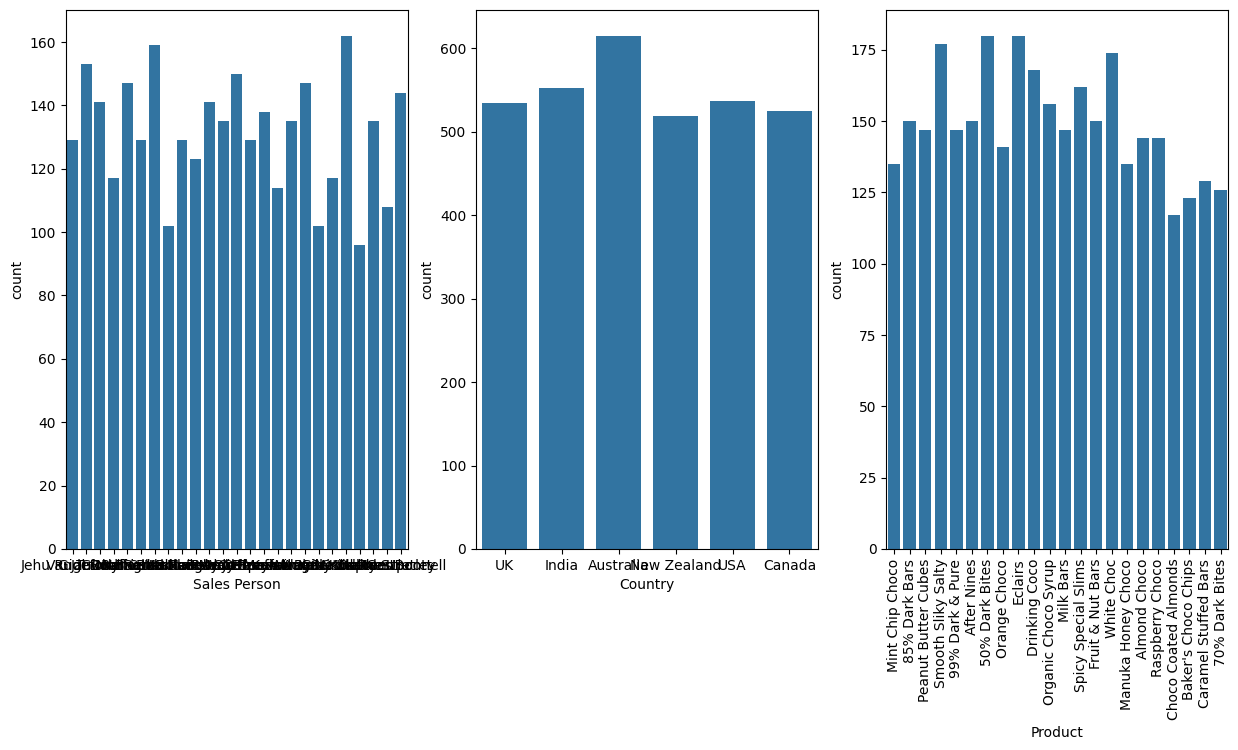

In [27]:
figure, axes = plt.subplots(1,3,figsize=(15,7))

for i ,col in enumerate(categorical_columns):
    sns.countplot(data=choco,x=col,ax=axes[i])
    plt.xticks(rotation = 90)

plt.show()

### total sales by months and years.

In [28]:
total_sales = pd.DataFrame(choco.groupby(['Year','Month'])['Amount'].sum())

In [29]:
total_sales

Amount
Year Month            
2022 1       896105.00
     2       699377.00
     3       749483.00
     4       674051.00
     5       752892.00
     6       865144.00
     7       803425.00
     8       743148.00
2023 1       958985.77
     2       749617.46
     3       807494.33
     4       727743.72
     5       811951.78
     6       932625.17
     7       861856.66
     8       793103.07
2024 1      1013621.82
     2       783102.44
     3       847791.96
     4       760132.50
     5       850906.79
     6       976162.77
     7       902250.63
     8       830599.99

### total sales to csv

In [50]:

total_sales.to_csv("../src/total_sales.csv",sep=",",encoding="utf-8")

In [41]:
product_sales = pd.DataFrame(choco.groupby("Product")["Amount"].sum())

In [42]:
product_sales

,Amount
Product,
50% Dark Bites,1087659.35
70% Dark Bites,677346.22
85% Dark Bars,955268.24
99% Dark & Pure,960033.45
After Nines,837215.67
Almond Choco,890454.65
Baker's Choco Chips,799085.67
Caramel Stuffed Bars,742516.15
Choco Coated Almonds,773062.91


In [49]:
product_sales.to_csv("../src/product_sales.csv",sep=",",encoding="utf-8")

In [46]:
country_revenue = pd.DataFrame(choco.groupby("Country")["Amount"].sum())

In [47]:
country_revenue

,Amount
Country,
Australia,3646444.35
Canada,3078495.65
India,3343730.83
New Zealand,3043654.04
UK,3365388.90
USA,3313858.09


In [48]:
country_revenue.to_csv("../src/country_revenue.csv",sep=",",encoding="utf-8")

### number of boxed shipped per product

In [51]:
boxes_shipped = pd.DataFrame(choco.groupby('Product')['Boxes Shipped'].sum())

In [54]:
boxes_shipped

,Boxes Shipped
Product,
50% Dark Bites,29810
70% Dark Bites,24524
85% Dark Bars,23828
99% Dark & Pure,24818
After Nines,25156
Almond Choco,20558
Baker's Choco Chips,21448
Caramel Stuffed Bars,26576
Choco Coated Almonds,19677


In [55]:
boxes_shipped.to_csv("../src/boxes_shipped_per_product.csv",sep=",",encoding="utf-8")

In [56]:
sales_person = pd.DataFrame(choco.groupby('Sales Person').agg(
    total_boxes = ('Boxes Shipped', 'sum'),
     total_amount = ('Amount', 'sum')  
))

In [57]:
sales_person

,total_boxes,total_amount
Sales Person,,
Andria Kimpton,19730,648214.81
Barr Faughny,19520,830826.91
Beverie Moffet,28027,892421.37
Brien Boise,24738,997326.48
Camilla Castle,16505,628613.13
Ches Bonnell,23070,1022599.96
Curtice Advani,21599,691797.92
Dennison Crosswaite,26862,931849.57
Dotty Strutley,20927,608101.17


In [58]:
sales_person.to_csv("../src/sales_person_portfolio.csv",sep=",",encoding="utf-8")

In [59]:
country_boxes_shipped = pd.DataFrame(choco.groupby("Country").agg(
    total_boxes_shipped = ('Boxes Shipped','sum')
))

In [60]:
country_boxes_shipped

,total_boxes_shipped
Country,
Australia,99618
Canada,95158
India,89968
New Zealand,81350
UK,92523
USA,81820


In [61]:
country_boxes_shipped.to_csv("../src/country_boxes.csv",sep=",",encoding="utf-8")

([<matplotlib.patches.Wedge at 0x1f9c3dcd160>,
 [Text(0.9206598691554153, 0.601984555721103, 'Australia'),
  Text(-0.15407863250410478, 1.0891555329729843, 'Canada'),
  Text(-1.031749415584367, 0.38143563472926567, 'India'),
  Text(-0.8811429570760329, -0.6584733018090443, 'New Zealand'),
  Text(0.08977617451195785, -1.096330350984592, 'UK'),
  Text(0.9779076915922409, -0.5036829823656294, 'USA')],
 [Text(0.5021781104484083, 0.32835521221151065, '18.4%'),
  Text(-0.08404289045678442, 0.5940848361670822, '17.6%'),
  Text(-0.5627724085005636, 0.2080558007614176, '16.6%'),
  Text(-0.4806234311323815, -0.3591672555322059, '15.1%'),
  Text(0.048968822461067915, -0.5979983732643228, '17.1%'),
  Text(0.5334041954139495, -0.2747361721994342, '15.1%')])

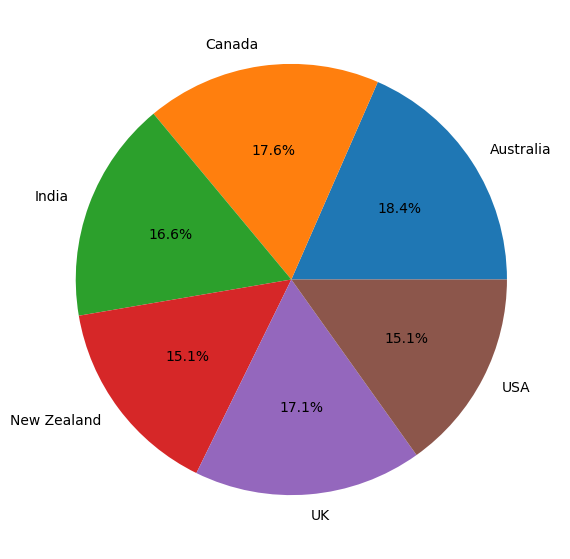

In [63]:
plt.figure(figsize=(15,7))
plt.pie(country_boxes_shipped['total_boxes_shipped'],labels = country_boxes_shipped.index,autopct ='%1.1f%%')